# Projec : Version B : Diabetes Diagnostic 
## Author : Yazan Maghary 
## Date : 05/01/2026 mm/dd/yyyy
## Data_Dictionary : [Data_Dict](https://docs.google.com/document/d/1QNZHliysHgTINXNo-IUZHDhzKnpI7mfia4gaKJ-97tg/edit?tab=t.0#heading=h.oo5xo3ir4vvl)
create a machine learning model to predict whether or not a patient has diabetes, based on certain diagnostic measurements included in this dataset.
> Table of Contents : 
1. [Importing Libraries](#Importing-Libraries)
2. [Load The Data Set](#Load-The-Data-Set)
3. [Check And Display The Data](#Check-And-Display-The-Data)
4. [Data Cleaning](#Data-Cleaning)
5. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
6. [Feature Engineering](#Feature-Engineering)
7. [Modeling And Evaluation](#Modeling-And-Evaluation)
8. [Conclusion](#Conclusion)

# Importing Libraries
* importing required libraries for the project
* importing required custom functions that need for the project

In [606]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split ,GridSearchCV ,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler , OneHotEncoder ,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn import set_config
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , ConfusionMatrixDisplay ,classification_report
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import  SMOTE
from imblearn.pipeline import  make_pipeline as make_pipeline_imb
from sklearn.metrics import accuracy_score , confusion_matrix , precision_score , recall_score ,ConfusionMatrixDisplay ,classification_report

## Custome Functions

> Custom Function
* Exploratory Data Analysis functions
* model evaluation function

In [620]:
def classification_metrics(y_true , y_pred , target_names ,label='', output_dict = False , fig_size = (8,4) , normalize = 'true' , cmap='Blues' , colorbar = False):
    report = classification_report(y_true , y_pred ,target_names=target_names)
    header = '-'*70
    print(header ,f"Classification metrics : {label}" , header ,sep="\n")
    print(report)
    fig ,axes = plt.subplots(figsize=fig_size , ncols=2)
    ConfusionMatrixDisplay.from_predictions(y_true , y_pred ,cmap='gist_gray',normalize=None , colorbar=colorbar ,ax=axes[0],display_labels=target_names)
    axes[0].set_title("Confusion Matrix")
     
    ConfusionMatrixDisplay.from_predictions(y_true , y_pred ,cmap=cmap ,normalize=normalize , colorbar=colorbar ,ax=axes[1],display_labels=target_names)
    axes[1].set_title("Normalized Confusion Matrix")
    fig.tight_layout()
    plt.show()
    if output_dict == True :
        report_dict = classification_report(y_true , y_pred ,output_dict=output_dict,target_names=target_names)
        return report_dict
    
    
def evaluation_classification(model , X_train , y_train , X_test , y_test , target_names ,figsize = (6,4) , normalize= 'true' , output_dict = False , cmap_train = 'Blues' , cmap_test = 'Reds' , colorbar = False):
    y_train_pred = model.predict(X_train)
    result_train = classification_metrics(y_train , y_train_pred ,output_dict=output_dict , fig_size=figsize , cmap=cmap_train , normalize=normalize , colorbar=colorbar ,label='Training Data' ,target_names=target_names)
    print()
    y_test_pred = model.predict(X_test)
    result_test = classification_metrics(y_test ,y_test_pred ,output_dict=output_dict , fig_size=figsize , cmap=cmap_train , normalize=normalize , colorbar=colorbar ,label='Testing Data' ,target_names=target_names)
    if output_dict == True :
        results_dit = {'train' : result_train , 'test' : result_test}
        print("Trainning Metrics")
        display(pd.DataFrame(results_dit['train']).round(2))
        print()
        print("Testing Metrics")
        display(pd.DataFrame(results_dit['test']).round(2))
   
        
def convert_probs_to_preds(probs , threshold ,pos_class = 1):
    predictions = [1 if prob[pos_class] > threshold else 0 for prob in probs]
    return predictions
def plot_threshold_metrics(model, X_test, y_test, 
                           start=0, stop=1.05, step=0.05,
                           pos_class=1, figsize=(15,5)):
    # Get probabilities
    y_probs = model.predict_proba(X_test)
    
    # Generate thresholds
    thresholds = np.arange(start=start, stop=stop, step=step)
    
    # Empty lists
    recalls     = []
    precisions  = []
    accuracies  = []

    # Iterate over thresholds
    for thresh in thresholds:
        preds = convert_probs_to_preds(y_probs, thresh, pos_class=pos_class)
        recalls.append(recall_score(y_test, preds))
        precisions.append(precision_score(y_test, preds))
        accuracies.append(accuracy_score(y_test, preds))

    # Plot
    plt.figure(figsize=figsize)
    plt.plot(thresholds, recalls,    label='Recall')
    plt.plot(thresholds, precisions, label='Precision')
    plt.plot(thresholds, accuracies, label='Accuracy')
    plt.legend()
    plt.title('Precision, Recall, and Accuracy Scores Across Decision Thresholds')
    plt.xlabel('Decision Thresholds')
    plt.ylabel('Score')
    plt.grid()
    plt.xticks(thresholds, rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Return as dataframe for reference
    results_df = pd.DataFrame({
        'Threshold' : thresholds,
        'Recall'    : recalls,
        'Precision' : precisions,
        'Accuracy'  : accuracies
    }).round(3)
    
    return results_df
def evaluate_with_threshold(model, X_train, y_train, X_test, y_test,
                             threshold=0.3, pos_class=1,
                             target_names=None,
                             figsize=(8,4), normalize='true',
                             cmap_train='Blues', cmap_test='Reds',
                             colorbar=False, output_dict=False):
    """
    Evaluates a model using a custom decision threshold.
    Shows classification metrics for both training and testing data.

    Parameters:
    -----------
    model        : fitted model with predict_proba method
    X_train      : training features
    y_train      : training labels
    X_test       : testing features
    y_test       : testing labels
    threshold    : decision threshold (default 0.3)
    pos_class    : positive class index (default 1)
    target_names : list of class names (default None)
    figsize      : figure size (default (8,4))
    normalize    : confusion matrix normalization (default 'true')
    cmap_train   : colormap for training matrix (default 'Blues')
    cmap_test    : colormap for testing matrix  (default 'Reds')
    colorbar     : show colorbar (default False)
    output_dict  : return metrics as dict (default False)
    """
    print(f"{'='*70}")
    print(f"  Threshold = {threshold}")
    print(f"{'='*70}\n")

    # Step 1 — Get probabilities
    y_train_probs = model.predict_proba(X_train)
    y_test_probs  = model.predict_proba(X_test)

    # Step 2 — Convert with threshold
    y_train_pred = convert_probs_to_preds(y_train_probs,
                                          threshold=threshold,
                                          pos_class=pos_class)
    y_test_pred  = convert_probs_to_preds(y_test_probs,
                                          threshold=threshold,
                                          pos_class=pos_class)

    # Step 3 — Show metrics
    result_train = classification_metrics(y_train, y_train_pred,
                                          target_names=target_names,
                                          label='Training Data',
                                          fig_size=figsize,
                                          normalize=normalize,
                                          cmap=cmap_train,
                                          colorbar=colorbar,
                                          output_dict=output_dict)
    print()
    result_test = classification_metrics(y_test, y_test_pred,
                                         target_names=target_names,
                                         label='Testing Data',
                                         fig_size=figsize,
                                         normalize=normalize,
                                         cmap=cmap_test,
                                         colorbar=colorbar,
                                         output_dict=output_dict)

    # Step 4 — Return dict if needed
    if output_dict:
        results = {'train': result_train, 'test': result_test}
        print("Training Metrics")
        display(pd.DataFrame(results['train']).round(2))
        print()
        print("Testing Metrics")
        display(pd.DataFrame(results['test']).round(2))
        return results

In [372]:
# UNIVARIATE PLOTTING FUNCTIONS FOR EDA
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):
  """Creates a seaborn countplot with the option to temporarily fill missing values
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x,hue=x, ax=ax, order=order,legend=False)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}", fontweight='bold')

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")

  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100

  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax


def explore_numeric(df, x, figsize=(6,5) ):
  """Creates a seaborn histplot and boxplot with a share x-axis,
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """

  ## Save null value counts and percent for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100


  ## Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])

  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])

  ## Adding a title
  axes[0].set_title(f"Column: {x}", fontweight='bold')

  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()


  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = df[x].nunique()
  print(f"- Unique Values: {nunique}")


  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, axes
"""MULTIVARIATE PLOTTING FUNCTIONS VS. NUMERIC TARGET"""

def plot_categorical_vs_target(df, x, y='charges',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',target_type = 'reg',
                            order = None):
  """Plots a combination of a seaborn barplot of means combined with
  a seaborn stripplot to show the spread of the data.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)
  if target_type == 'reg':
    
    # Barplot
    sns.barplot(data=temp_df, x=x,hue=x ,legend=False, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
    sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  else :
    ax = sns.histplot(data=temp_df , x = x , hue = y ,stat = 'percent' ,multiple='fill' )
  # Rotate xlabels
  ax.set_xticks(ax.get_xticks())
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}", fontweight='bold')
  fig.tight_layout()
  return fig, ax


def plot_numeric_vs_target(df, x, y, figsize=(6,4),
                           target_type='reg', estimator='mean',
                           errorbar='ci',sorted=False,ascending=False,
                           **kwargs): # kwargs for sns.regplot

  nulls = df[[x,y]].isna().sum()
  if nulls.sum()>0:
    print(f"- Excluding {nulls.sum()} NaN's")
    # print(nulls)
    temp_df = df.dropna(subset=[x,y,])
  else:
    temp_df = df
  # Create the figure
  fig, ax = plt.subplots(figsize=figsize)

  # REGRESSION-TARGET PLOT
  if 'reg' in target_type:
    # Calculate the correlation
    corr = df[[x,y]].corr().round(2)
    r = corr.loc[x,y]
    # Plot the data
    scatter_kws={'ec':'white','alpha':0.8,}
    sns.regplot(data=temp_df, x=x, y=y, ax=ax, scatter_kws=scatter_kws, **kwargs) # Included the new argument within the sns.regplot function
    
    ## Add the title with the correlation
    ax.set_title(f"{x} vs. {y} (r = {r})")

  # CLASSIFICATION-TARGET PLOT
  elif 'class' in target_type:

    # Sort the groups by median/mean
    if sorted == True:

      if estimator == 'median':
        group_vals = temp_df.groupby(y)[x].median()
      elif estimator =='mean':
        group_vals = temp_df.groupby(y)[x].mean()

      ## Sort values
      group_vals = group_vals.sort_values(ascending=ascending)
      order = group_vals.index
    else:
      # Set order to None if not calcualted
      order = None
    # Left Subplot (barplot)
    sns.barplot(data=temp_df, x=y, y=x, order=order,  estimator=estimator,
                errorbar=errorbar, ax=ax, **kwargs)

    # Add title
    ax.set_title(f"{x} vs. {y}")

    # rotate xaxis labels
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


  # Final Adjustments & return
  fig.tight_layout()
  fig.show()
  return fig, ax

# Load The Data Set

In [373]:
path = 'D:\Computer Systems Engineering\Data Sciecne\AXSOSACADEMY\\02-IntroML\Diabetes_Predection\Data\Belt2_B_diabetes_v2_final.csv'
df = pd.read_csv(path)
set_config(transform_output="pandas")
display(df.head(3) , df.info())

<class 'pandas.DataFrame'>
RangeIndex: 642 entries, 0 to 641
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               642 non-null    int64  
 1   Glucose                   638 non-null    float64
 2   BloodPressure             616 non-null    float64
 3   SkinThickness             455 non-null    float64
 4   Insulin                   331 non-null    float64
 5   DiabetesPedigreeFunction  642 non-null    str    
 6   WeightGroup               642 non-null    str    
 7   AgeGroup                  642 non-null    str    
 8   Gender                    642 non-null    str    
 9   Outcome                   642 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 50.3 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,WeightGroup,AgeGroup,Gender,Outcome
0,4,189.0,110.0,31.0,NaN,0_68,overweight,18 - 44,F,0
1,2,157.0,74.0,35.0,440.0,0.134,obese_2,18 - 44,F,0
2,6,98.0,58.0,33.0,190.0,0.43,obese_1,18 - 44,F,0


None

# Check And Display The Data

In [374]:
data_info = df.info() 
data_describe = df.describe()
data_head = df.head(3)
data_tail = df.tail(3)
data_nuniqe = df.nunique()
print(data_info)
display(data_describe)    
display(data_head)   
display(data_tail)
print(data_nuniqe)

<class 'pandas.DataFrame'>
RangeIndex: 642 entries, 0 to 641
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               642 non-null    int64  
 1   Glucose                   638 non-null    float64
 2   BloodPressure             616 non-null    float64
 3   SkinThickness             455 non-null    float64
 4   Insulin                   331 non-null    float64
 5   DiabetesPedigreeFunction  642 non-null    str    
 6   WeightGroup               642 non-null    str    
 7   AgeGroup                  642 non-null    str    
 8   Gender                    642 non-null    str    
 9   Outcome                   642 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 50.3 KB
None


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,Outcome
count,642.000000,638.000000,616.000000,455.000000,331.000000,642.000000
mean,5.453271,124.043887,72.397727,29.483516,158.996979,0.422118
std,39.460225,30.756980,12.306886,10.527458,117.255057,0.494282
min,0.000000,56.000000,24.000000,7.000000,14.000000,0.000000
25%,1.000000,100.000000,64.000000,22.000000,82.500000,0.000000
50%,3.000000,121.000000,72.000000,30.000000,130.000000,0.000000
75%,6.000000,144.000000,80.000000,36.500000,192.500000,1.000000
max,1000.000000,199.000000,114.000000,99.000000,846.000000,1.000000


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,WeightGroup,AgeGroup,Gender,Outcome
0,4,189.0,110.0,31.0,NaN,0_68,overweight,18 - 44,F,0
1,2,157.0,74.0,35.0,440.0,0.134,obese_2,18 - 44,F,0
2,6,98.0,58.0,33.0,190.0,0.43,obese_1,18 - 44,F,0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,WeightGroup,AgeGroup,Gender,Outcome
639,8,176.0,90.0,34.0,300.0,0.467,obese_1,45 - 64,F,1
640,0,104.0,64.0,37.0,64.0,0.51,obese_1,18 - 44,M,1
641,0,180.0,78.0,63.0,14.0,2.42,obsese_3,18 - 44,M,1


Pregnancies                  17
Glucose                     131
BloodPressure                43
SkinThickness                48
Insulin                     175
DiabetesPedigreeFunction    470
WeightGroup                   7
AgeGroup                      4
Gender                        3
Outcome                       2
dtype: int64


# Data Cleaning

## Duplicated

In [375]:
dup_vals = df.duplicated(keep=False).sum()
print("Data contains", dup_vals, "duplicated rows.")

Data contains 6 duplicated rows.


In [376]:
df = df.drop_duplicates()
dup_vals = df.duplicated(keep=False).sum()
print("Data contains", dup_vals, "duplicated rows.")

Data contains 0 duplicated rows.


## Null Values
> We notice that three features have nulls values , and looking to the boxplot , we can notice that they have outliers , so we impute them with the median value later in modeling phase 

In [377]:
null_vals = df.isna()
print("Data contains", null_vals.sum().sum(), "null values.")
print("-"*100)
print("-"*100)
display(null_vals.sum()[null_vals.sum() > 0])

Data contains 524 null values.
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------


Glucose            4
BloodPressure     26
SkinThickness    185
Insulin          309
dtype: int64

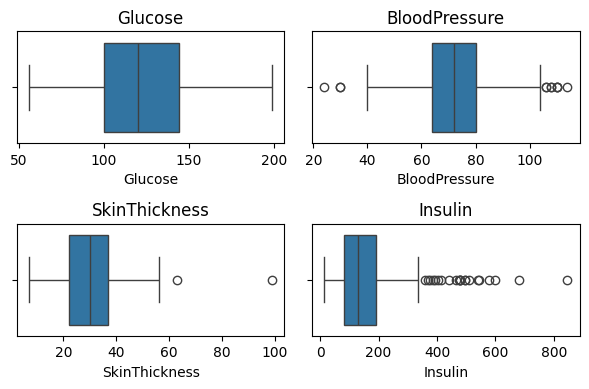

In [378]:
fig , axes = plt.subplots(figsize=(6,4), ncols=2 , nrows=2)
sns.boxplot(data=df, x='Glucose', ax=axes[0][0])
axes[0][0].set_title("Glucose")
sns.boxplot(data=df, x='BloodPressure', ax=axes[0][1])
axes[0][1].set_title("BloodPressure")
sns.boxplot(data=df, x='SkinThickness', ax=axes[1][0])
axes[1][0].set_title("SkinThickness")
sns.boxplot(data=df, x='Insulin', ax=axes[1][1])
axes[1][1].set_title("Insulin")
fig.tight_layout()
plt.show()
# cols_with_nulls = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin']
# for col in cols_with_nulls:
#     df[col] = df[col].fillna(df[col].median())
# print(df[cols_with_nulls].isnull().sum())

## Inconsistent Values
* converting DiabetesPedigreeFunction to float after replacing _ with .
* Replacing > with < in AgeGroup
* Replacing m with M in Gender
* Pregnancies equal to 1000 its impossible to have 1000 pregnancies so we replace it with 10 to make sense

In [379]:
cat_cols = df.select_dtypes(include='object').columns
for cat in cat_cols:
    print("*"*100)
    print(f"Value Count in {cat} : {df[cat].value_counts()}")
    print("*"*100)
    print("*"*100)

****************************************************************************************************
Value Count in DiabetesPedigreeFunction : DiabetesPedigreeFunction
0.254                  5
0.26                   4
0.304                  4
0.19699999999999998    4
0.258                  4
                      ..
0.605                  1
0.479                  1
0.467                  1
0.51                   1
2.42                   1
Name: count, Length: 470, dtype: int64
****************************************************************************************************
****************************************************************************************************
****************************************************************************************************
Value Count in WeightGroup : WeightGroup
obese_1           195
overweight        146
obese_2           126
obsese_3           86
healthy weight     74
MISSING             8
underweight         4
Name: count, dtype: 

C:\Users\zezo2\AppData\Local\Temp\ipykernel_19300\1897937721.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [380]:
# DiabetesPedigreeFunction  
df['DiabetesPedigreeFunction'] = df['DiabetesPedigreeFunction'].str.replace('_', '.')
df['DiabetesPedigreeFunction'] = df['DiabetesPedigreeFunction'].astype(float).round(2)


In [381]:
# AgeGroup 
df['AgeGroup'] = df['AgeGroup'].str.replace('<', '>')
df['AgeGroup'].value_counts()

AgeGroup
18 - 44    526
45 - 64    102
>65         11
Name: count, dtype: int64

In [382]:
# Gender 
df['Gender'] = df['Gender'].str.replace('m', 'M')

In [383]:
cat_cols = df.select_dtypes(include='object').columns
for cat in cat_cols:
    print("*"*100)
    print(f"Value Count in {cat} : {df[cat].value_counts()}")
    print("*"*100)
    print("*"*100)


****************************************************************************************************
Value Count in WeightGroup : WeightGroup
obese_1           195
overweight        146
obese_2           126
obsese_3           86
healthy weight     74
MISSING             8
underweight         4
Name: count, dtype: int64
****************************************************************************************************
****************************************************************************************************
****************************************************************************************************
Value Count in AgeGroup : AgeGroup
18 - 44    526
45 - 64    102
>65         11
Name: count, dtype: int64
****************************************************************************************************
****************************************************************************************************
*******************************************************************

C:\Users\zezo2\AppData\Local\Temp\ipykernel_19300\698312252.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [384]:
# pregnancies equal 1000 its impposible
display(
df.loc[df['Pregnancies'] > 13 , 'Pregnancies'])
df.loc[df['Pregnancies'] > 13 ]
# assumed that 2 zeros are errors
print('-'*100)
print('-'*100)
df['Pregnancies'] = df['Pregnancies'].replace(1000, 10)
display(
df.loc[df['Pregnancies'] > 13 , 'Pregnancies'])


371    1000
498      14
538      14
559      15
Name: Pregnancies, dtype: int64

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------


498    14
538    14
559    15
Name: Pregnancies, dtype: int64

In [385]:
df['WeightGroup'] = df['WeightGroup'].str.replace('obsese_3' , 'obese_3')

# Exploratory Data Analysis
> Best Approach :
* make a copy of data frame only to visualize
* convert the Outcome to categorical feature for an easy understanding 0 = No Diabetes , 1 = Diabetes

In [386]:
df_copy = df.copy()
replace_fire_alarm = {
    0 : 'No Diabetes',
    1 : 'Diabetes'
}
df_copy['Outcome'] = df_copy['Outcome'].replace(replace_fire_alarm)
df_copy['Outcome'].value_counts()
# imputing null_values 
num_cols = df_copy.select_dtypes(include='number').columns
df_copy[num_cols] = SimpleImputer(strategy='median').fit_transform(df_copy[num_cols])
df_copy.isna().sum()
# df_copy.to_csv('D:\Computer Systems Engineering\Data Sciecne\AXSOSACADEMY\\02-IntroML\Diabetes_Predection\Data\Belt2_B_diabetes_v2_cleaned.csv') ## Already saved

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
DiabetesPedigreeFunction    0
WeightGroup                 0
AgeGroup                    0
Gender                      0
Outcome                     0
dtype: int64

## Numeric Feature Visualization
 ###   Column           | Dtype  
---  ------                    --------------  -----  
 1.  Glucose         |   float64
 2.  BloodPressure     |    float64
 3.  SkinThickness |  float64
 4.  Insulin         |   float64   
 5. Pregnancies | int

### Glucose 

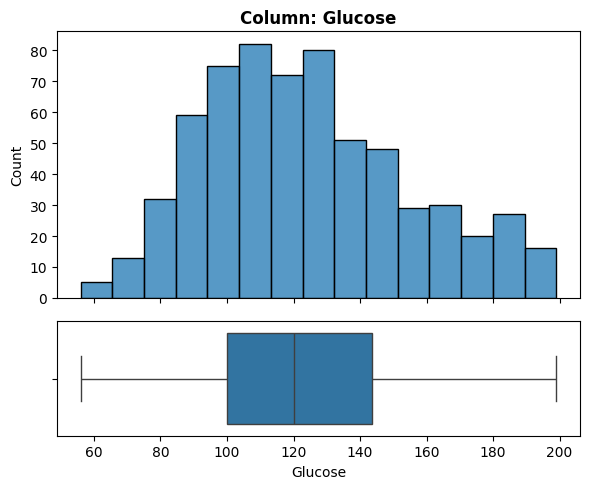

- NaN's Found: 0 (0.0%)
- Unique Values: 131
- Most common value: '99.0' occurs 15 times (2.35%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: Glucose'}, xlabel='Glucose', ylabel='Count'>,
        <Axes: xlabel='Glucose'>], dtype=object))

In [387]:
feature = 'Glucose'
target = 'Outcome'
explore_numeric(df_copy , x=feature)

> We can Note :
* Feature : Glucose , type : numeric
* Null Values : 4 , percent : 0.63% 
* Would we know this BEFORE the target is determined?
  - ... Yes

* Is there a business case/understanding reason to exclude based on our business case?
  - ... No there is no business case to exclude this feature


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Glucose vs. Outcome'}, xlabel='Glucose', ylabel='Percent'>)

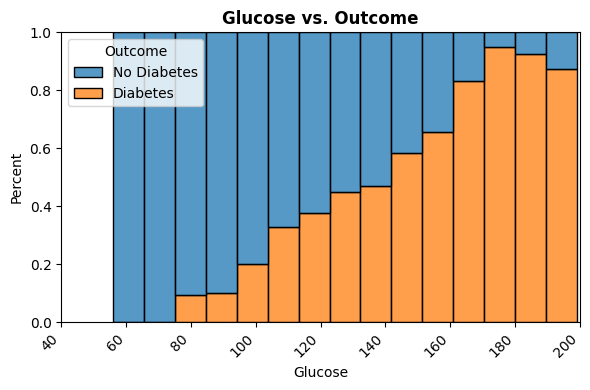

In [388]:
# Glucose vs Target(outcome)
plot_categorical_vs_target(df_copy, x=feature, y=target, target_type='class')

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - `...` Yest , Glucose is a predictor of Diabetes
  - Does this feature appear to be a predictor of the target?
    - `...` Yes , we can notice that who have diabetes have a higher Glucose level

### BloodPressure

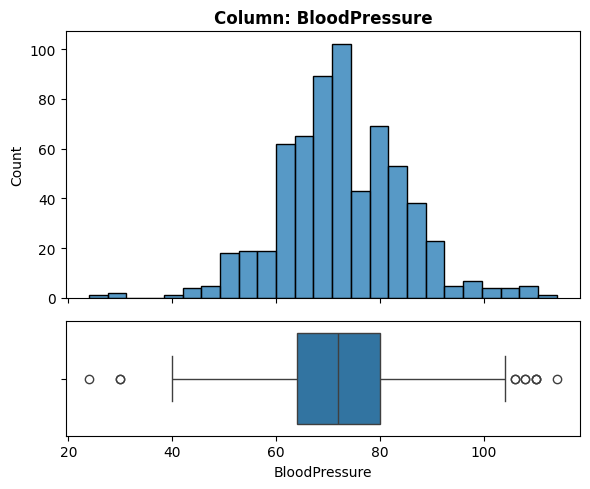

- NaN's Found: 0 (0.0%)
- Unique Values: 43
- Most common value: '72.0' occurs 60 times (9.39%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: BloodPressure'}, xlabel='BloodPressure', ylabel='Count'>,
        <Axes: xlabel='BloodPressure'>], dtype=object))

In [389]:
feature = 'BloodPressure'
explore_numeric(df_copy , x=feature)

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'BloodPressure vs. Outcome'}, xlabel='BloodPressure', ylabel='Percent'>)

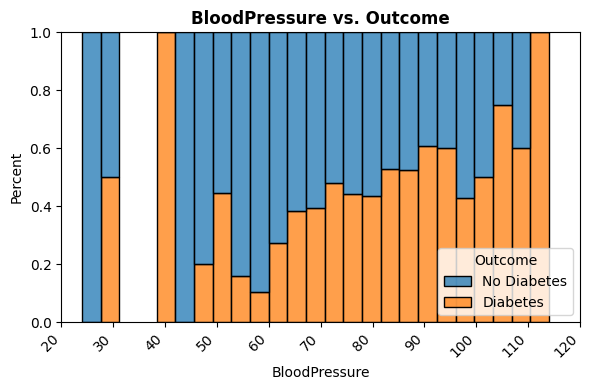

In [390]:
plot_categorical_vs_target(df_copy, x=feature, y= target,target_type = 'class')


- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - `...` Yes , BloodPressure is a predictor of Diabetes , but not a strong one
  - Does this feature appear to be a predictor of the target?
    - `...` Yes , we can notice that who have diabetes have a higher BloodPressure level , but it is not a strong predictor 

### SkinThickness

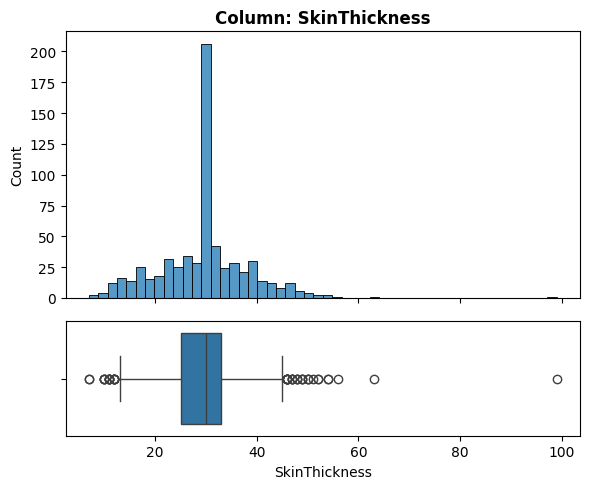

- NaN's Found: 0 (0.0%)
- Unique Values: 48
- Most common value: '30.0' occurs 206 times (32.24%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: SkinThickness'}, xlabel='SkinThickness', ylabel='Count'>,
        <Axes: xlabel='SkinThickness'>], dtype=object))

In [391]:
feature='SkinThickness'
explore_numeric(df_copy , x=feature)


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'SkinThickness vs. Outcome'}, xlabel='SkinThickness', ylabel='Percent'>)

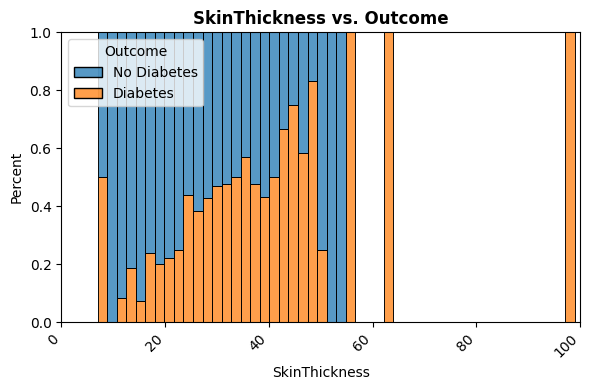

In [392]:
plot_categorical_vs_target(df_copy, x=feature, y=target, target_type='class')


- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - `...` Yes 
  - Does this feature appear to be a predictor of the target?
    - `...` Yes , we can notice that who have diabetes have a higher SkinThickness level

### Insulin

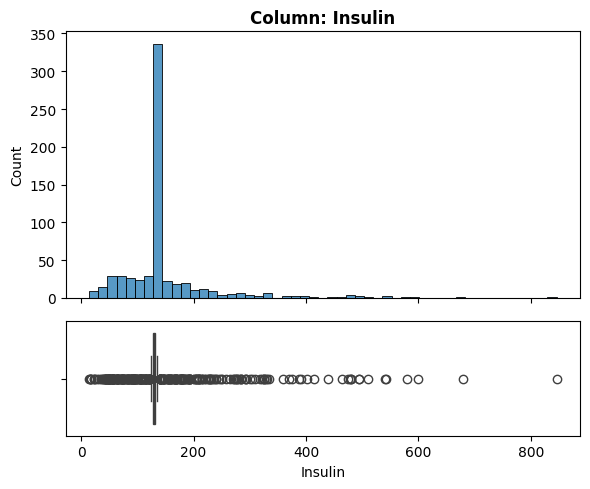

- NaN's Found: 0 (0.0%)
- Unique Values: 175
- Most common value: '130.0' occurs 317 times (49.61%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: Insulin'}, xlabel='Insulin', ylabel='Count'>,
        <Axes: xlabel='Insulin'>], dtype=object))

In [393]:
feature = 'Insulin'
explore_numeric(df_copy , x=feature)

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Insulin vs. Outcome'}, xlabel='Insulin', ylabel='Percent'>)

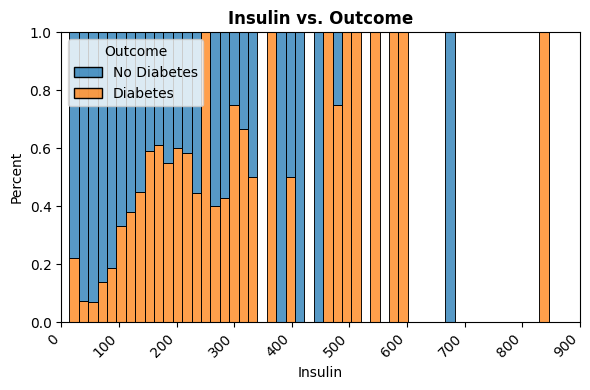

In [394]:
plot_categorical_vs_target(df_copy, x=feature, y=target, target_type='class')


- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - `...` Yes , but its weak predictor
  - Does this feature appear to be a predictor of the target?
    - `...` Yes, we can notice that who have diabetes have a higher Insulin level , but it is not a strong predictor

### Pregnancies

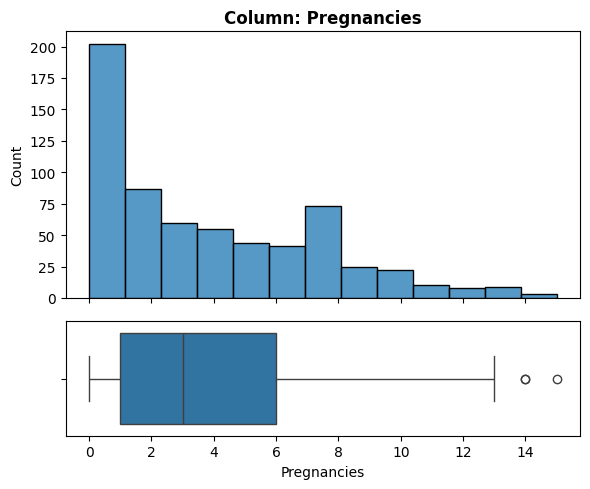

- NaN's Found: 0 (0.0%)
- Unique Values: 16
- Most common value: '1.0' occurs 108 times (16.9%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: Pregnancies'}, xlabel='Pregnancies', ylabel='Count'>,
        <Axes: xlabel='Pregnancies'>], dtype=object))

In [395]:
feature = 'Pregnancies'
explore_numeric(df_copy , x=feature)

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Pregnancies vs. Outcome'}, xlabel='Pregnancies', ylabel='Percent'>)

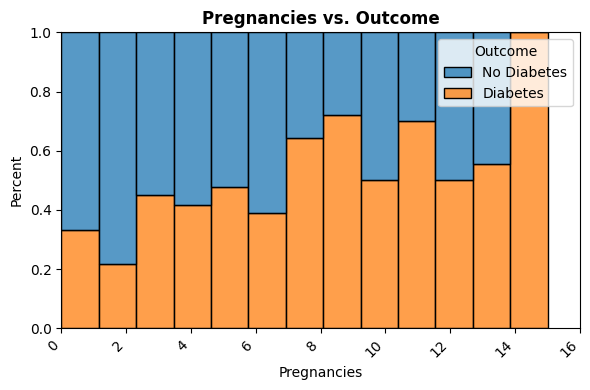

In [396]:
plot_categorical_vs_target(df_copy, x=feature, y=target ,target_type='class' )


- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - `...` Yes , Pregnancies is a predictor of Diabetes
  - Does this feature appear to be a predictor of the target?
    - `...` Yes , we can notice that who had a higher number of Pregnancies had a higher chance of having diabetes

## Categorical Feature Visualization
 ###   Column           | Dtype  
---  ------                    --------------  -----  
 1.  WeightGroup         |   str
 2.  AgeGroup     |    str
 3.  Gender |  str

### WeightGroup

C:\Users\zezo2\AppData\Local\Temp\ipykernel_19300\3651771871.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


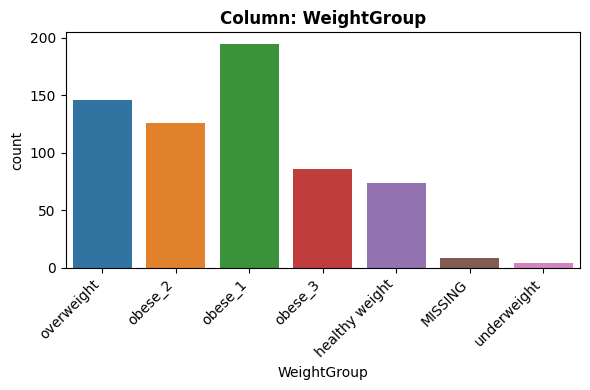

- NaN's Found: 0 (0.0%)
- Unique Values: 7
- Most common value: 'obese_1' occurs 195 times (30.52%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: WeightGroup'}, xlabel='WeightGroup', ylabel='count'>)

In [397]:
explore_categorical(df_copy , 'WeightGroup')

> We can Note :
* Feature : WeightGroup , type : str
* Null Values : 0 , percent : 0% 
* Most common value : obese_1 , occurs 195 times (30.52%)
* its not constant or quasi-constant.
* Unique values : 7 , its low cardinality
* Would we know this BEFORE the target is determined?
  - ... Yes

* Is there a business case/understanding reason to exclude based on our business case?
  - ... No there is no business case to exclude this feature

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'WeightGroup vs. Outcome'}, xlabel='WeightGroup', ylabel='Percent'>)

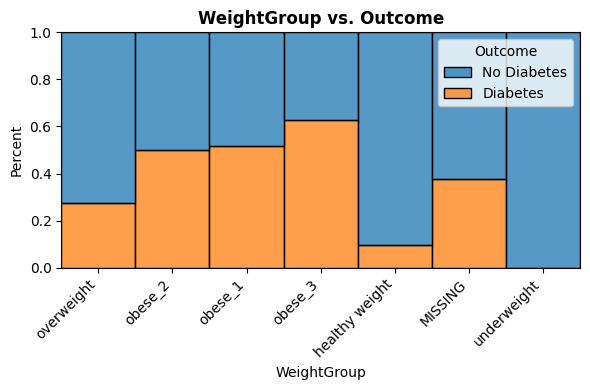

In [398]:
plot_categorical_vs_target(df_copy , 'WeightGroup' , 'Outcome' , target_type='class')

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - `...` Yes 
  - Does this feature appear to be a predictor of the target?
    - `...` Yes , we can notice that who have a healthy weight or under weight have a less chance to had diabetes than who have over weight or obses_3,2,1

### AgeGroup

C:\Users\zezo2\AppData\Local\Temp\ipykernel_19300\3651771871.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


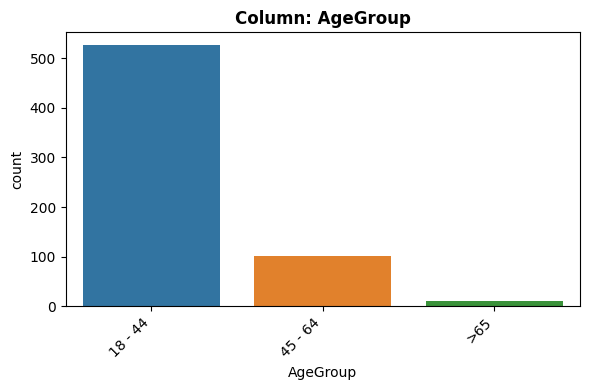

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: '18 - 44' occurs 526 times (82.32%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: AgeGroup'}, xlabel='AgeGroup', ylabel='count'>)

In [399]:
explore_categorical(df_copy , 'AgeGroup')

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'AgeGroup vs. Outcome'}, xlabel='AgeGroup', ylabel='Percent'>)

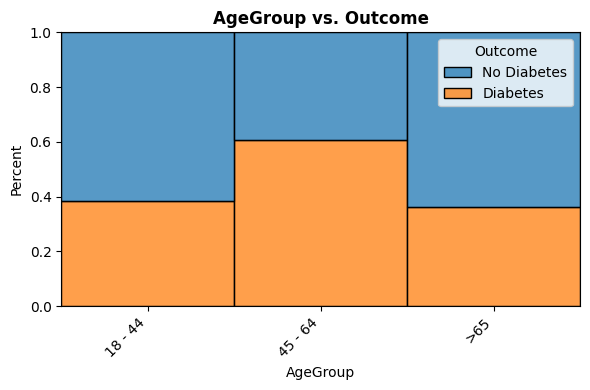

In [400]:
plot_categorical_vs_target(df_copy , 'AgeGroup' , 'Outcome' , target_type='class')

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - `...` Yes
  - Does this feature appear to be a predictor of the target?
    - `...` Yes , people in age interval 45-64 have higher chance of having diabetes than others 

### Gender

C:\Users\zezo2\AppData\Local\Temp\ipykernel_19300\3651771871.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


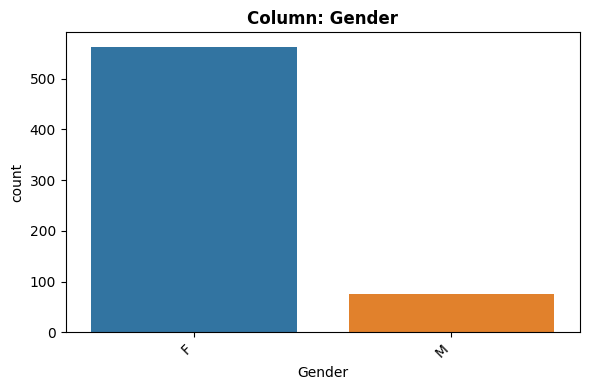

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'F' occurs 563 times (88.11%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: Gender'}, xlabel='Gender', ylabel='count'>)

In [401]:
explore_categorical(df_copy , x='Gender')

> We can Note :
* Feature : Gender , type : str
* Null Values : 0 , percent : 0%  
* Most common value : Female , occurs 563 times (88.11%)
* its a quasi-constant.
* Unique values : 2 , its low cardinality
* Would we know this BEFORE the target is determined?
  - ... Yes

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Gender vs. Outcome'}, xlabel='Gender', ylabel='Percent'>)

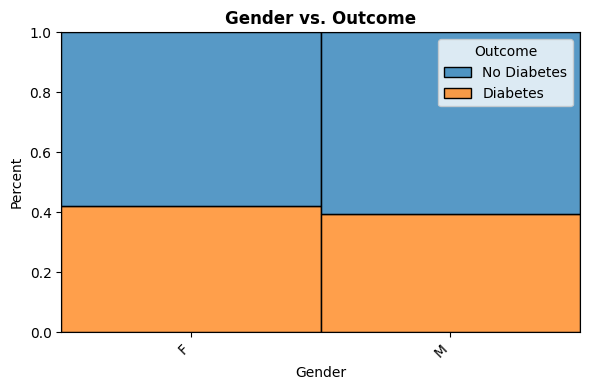

In [402]:
plot_categorical_vs_target(df_copy, x='Gender', y='Outcome',target_type='class')

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - `...` Yes , it's a predictor of the target
  - Does this feature appear to be a predictor of the target?
    - `...` Yes , female have a higher chance of having Diabetes

# Feature Engineering
> note : we will continuo work with original data set 

### Train Test Split

In [403]:
print(f"target is {target}")
y = df[target]
X = df.drop(columns=[target])
X_train , X_test , y_train , y_test = train_test_split(X ,y ,random_state=42)
display(X_train.head(3))
print("*"*100 , '*'*100 ,sep='\n')
display(y_train.head(3))

target is Outcome


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,WeightGroup,AgeGroup,Gender
305,0,93.0,100.0,39.0,72.0,1.02,obese_3,18 - 44,F
546,3,121.0,52.0,NaN,NaN,0.13,obese_2,18 - 44,F
515,2,155.0,74.0,17.0,96.0,0.43,overweight,18 - 44,F


****************************************************************************************************
****************************************************************************************************


305    0
546    1
515    1
Name: Outcome, dtype: int64

### Define columns

In [404]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include='number').columns
print( "Categorical Columns :\n", cat_cols)
print("-"*100)
print("Numeric Columns :\n",num_cols)

Categorical Columns :
 Index(['WeightGroup', 'AgeGroup', 'Gender'], dtype='str')
----------------------------------------------------------------------------------------------------
Numeric Columns :
 Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction'],
      dtype='str')


C:\Users\zezo2\AppData\Local\Temp\ipykernel_19300\2020692375.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns


### Preprocessing

In [405]:
# numeric 
num_imputer = SimpleImputer(strategy='median')
num_scaler = StandardScaler()
num_pipe = make_pipeline(num_imputer , num_scaler)
num_tuple_scale = ('Numeric' , num_pipe , num_cols)
num_tuple = ('Numeric' , num_imputer , num_cols)


In [413]:
# Ordinal Columns 
ord_enc = OrdinalEncoder(categories=[
    ['underweight', 'healthy weight', 'obese_1' ,'obese_2' ,'obese_3' , 'overweight' , 'MISSING']  ,["18 - 44", "45 - 64",">65"]    
],handle_unknown='error')
ord_cols = cat_cols.drop('Gender')
ord_scale = StandardScaler()
ord_pipe_scale = make_pipeline(ord_enc , ord_scale)
ord_tuple = ('ordinal', ord_enc, ord_cols)
ord_tuple_scale = ('ordinal', ord_pipe_scale, ord_cols)
ord_cols
df[ord_cols].value_counts()

WeightGroup     AgeGroup
obese_1         18 - 44     159
overweight      18 - 44     118
obese_2         18 - 44     102
obese_3         18 - 44      76
healthy weight  18 - 44      61
obese_1         45 - 64      33
overweight      45 - 64      25
obese_2         45 - 64      21
healthy weight  45 - 64      12
obese_3         45 - 64      10
MISSING         18 - 44       6
underweight     18 - 44       4
obese_2         >65           3
overweight      >65           3
obese_1         >65           3
healthy weight  >65           1
MISSING         >65           1
                45 - 64       1
Name: count, dtype: int64

In [414]:
# CatCOls 
ohe_cols = cat_cols.drop(ord_cols)
ohe = OneHotEncoder(sparse_output=False , handle_unknown='ignore')
ohe_tuple = ('categorical' , ohe ,ohe_cols)
ohe_cols


Index(['Gender'], dtype='str')

In [420]:
# Preprocessing 
cols_tranf = ColumnTransformer([num_tuple , ord_tuple , ohe_tuple],verbose_feature_names_out=False,remainder='drop')
cols_tranf_scale = ColumnTransformer([num_tuple_scale , ord_tuple_scale , ohe_tuple],verbose_feature_names_out=False,remainder='drop')


# Modeling And Evaluation
> First  : We will use 2 models to predict the target ,then trying to tune them to get the best result 
* Logistic Regression
* Random Forest Classifier

## Logistic Regression 
* Logistic Regression is a widely employed algorithm for binary classification tasks.
* we should use scaling with Logistic Regression
* if our model perfomance is not good enough , we can tune it , if doesn't help , we can try another model

In [421]:
log_reg = LogisticRegression(random_state=42)
log_reg_pipe = make_pipeline(cols_tranf_scale , log_reg)
log_reg_pipe.fit(X_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numeric', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

----------------------------------------------------------------------
Classification metrics : Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.76      0.79      0.77       260
    Diabetes       0.74      0.70      0.72       219

    accuracy                           0.75       479
   macro avg       0.75      0.75      0.75       479
weighted avg       0.75      0.75      0.75       479



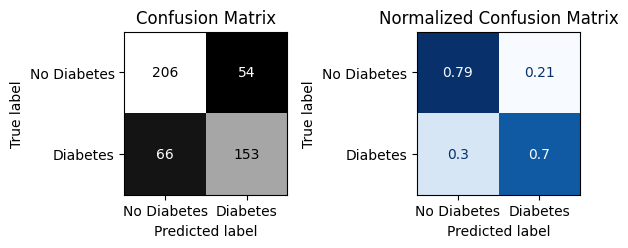


----------------------------------------------------------------------
Classification metrics : Testing Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.84      0.75      0.79       111
    Diabetes       0.54      0.67      0.60        49

    accuracy                           0.72       160
   macro avg       0.69      0.71      0.70       160
weighted avg       0.75      0.72      0.73       160



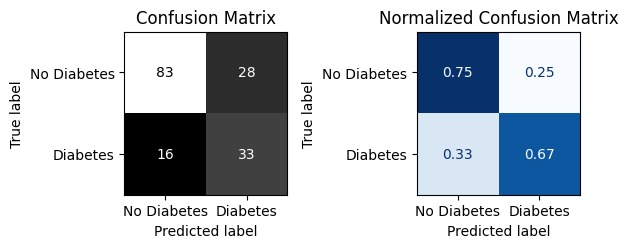

In [423]:
evaluation_classification(log_reg_pipe , X_train , y_train , X_test , y_test , target_names=['No Diabetes' , 'Diabetes'])

> We can note that :
* **No Overfitting** — The gap between training and testing metrics
  is very small 0.03, indicating the model generalizes well
  to unseen data.
* **Recall is Our Priority** — For diabetes prediction, missing a
  real case is more dangerous than a false alarm. We focus on
  maximizing recall over precision.
* **Diabetes Recall = 0.67** — The model correctly identifies 67%
  of true diabetes cases, meaning 33% of actual diabetes patients
  are missed. This is a limitation that needs improvement. 
* **Low Diabetes Precision = 0.54** — Only 54% of predicted diabetes
  cases are truly diabetic, meaning 46% are false alarms.
> We could tune the model ,trying to improve the perfromance of recall score
* using SMOTE for balancing 

> after i googled a bit , i found best tune parameters for Logistic Regression 
* link : https://www.geeksforgeeks.org/machine-learning/how-to-optimize-logistic-regression-performance/#understanding-logistic-regression
* link for balancing using smote : https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/

In [ ]:
log_reg_pipe.get_params()


{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('Numeric',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
          'DiabetesPedigreeFunction'],
         dtype='str')),
                                   ('ordinal',
                                    Pipeline(steps=[('ordinalencoder',
                                                     OrdinalEncoder(categories=[['underweight',
                                                                                 'healthy '
                                                                                 'weight',
                          

In [568]:
param_grid_lr = {
    'logisticregression__C'            : [0.001, 0.01, 0.1, 1, 10],
    'logisticregression__penalty'      : ['l2'],      
    'logisticregression__solver'      : ['lbfgs', 'saga'], 
    # l2 best for recall
}

In [569]:
log_reg = LogisticRegression(random_state=42 , max_iter=1000)
log_reg_pipe = make_pipeline_imb(cols_tranf_scale,SMOTE(random_state=42) , log_reg)
grid = GridSearchCV(log_reg_pipe , param_grid_lr , cv=5 , n_jobs=-1,scoring='recall')
grid.fit(X_train , y_train)

C:\Users\zezo2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logisticregression__C': [0.001, 0.01, ...], 'logisticregression__penalty': ['l2'], 'logisticregression__solver': ['lbfgs', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold

----------------------------------------------------------------------
Classification metrics : Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.78      0.77      0.77       260
    Diabetes       0.73      0.75      0.74       219

    accuracy                           0.76       479
   macro avg       0.76      0.76      0.76       479
weighted avg       0.76      0.76      0.76       479



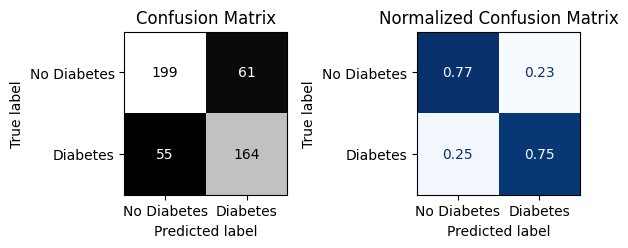


----------------------------------------------------------------------
Classification metrics : Testing Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.85      0.73      0.79       111
    Diabetes       0.54      0.71      0.61        49

    accuracy                           0.72       160
   macro avg       0.70      0.72      0.70       160
weighted avg       0.76      0.72      0.73       160



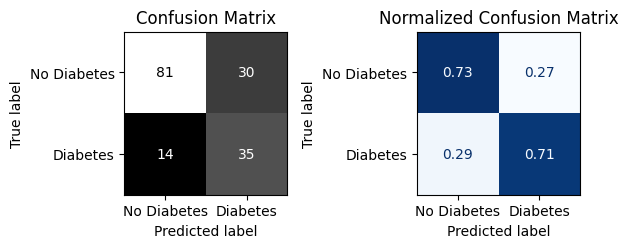

In [570]:
evaluation_classification(grid.best_estimator_ , X_train , y_train , X_test , y_test , target_names=['No Diabetes' , 'Diabetes'])

> we note that we improve the performance of recall score for like 5% , which is good
* recall score : 71 % , we cant depend on it 
* so we will try ato threshold to get better result , focusing on recall

C:\Users\zezo2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


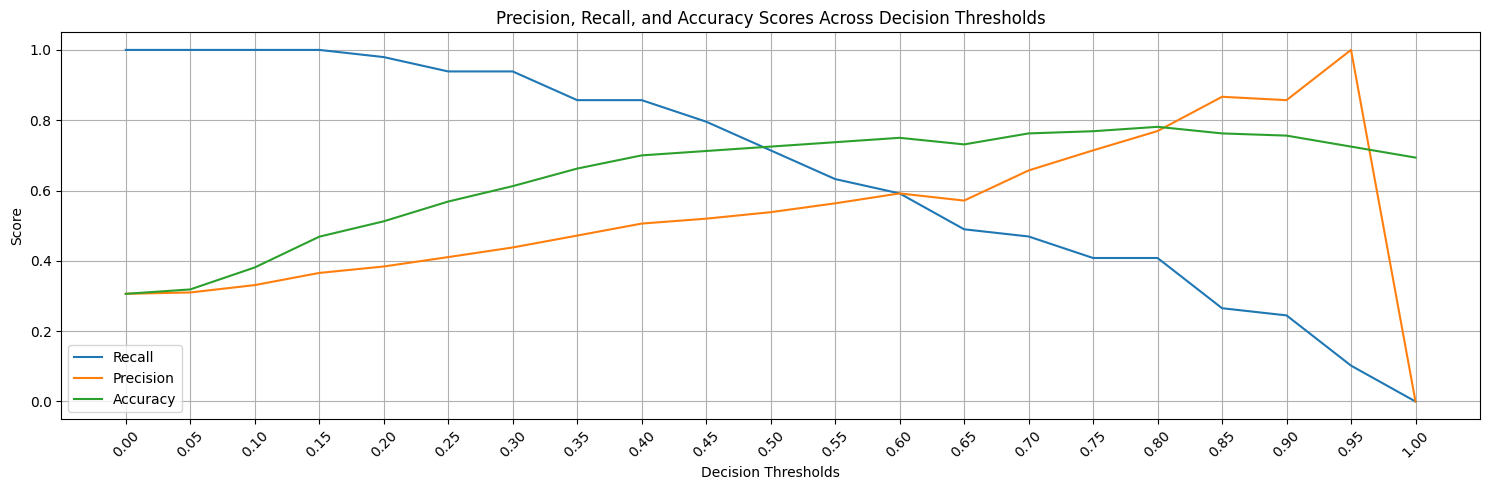

,Threshold,Recall,Precision,Accuracy
0,0.00,1.000,0.306,0.306
1,0.05,1.000,0.310,0.319
2,0.10,1.000,0.331,0.381
3,0.15,1.000,0.366,0.469
4,0.20,0.980,0.384,0.512
5,0.25,0.939,0.411,0.569
6,0.30,0.939,0.438,0.612
7,0.35,0.857,0.472,0.662
8,0.40,0.857,0.506,0.700
9,0.45,0.796,0.520,0.712


In [618]:
plot_threshold_metrics(grid.best_estimator_, X_test, y_test)

  Threshold = 0.3

----------------------------------------------------------------------
Classification metrics : Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.86      0.55      0.67       260
    Diabetes       0.63      0.89      0.74       219

    accuracy                           0.71       479
   macro avg       0.74      0.72      0.70       479
weighted avg       0.75      0.71      0.70       479



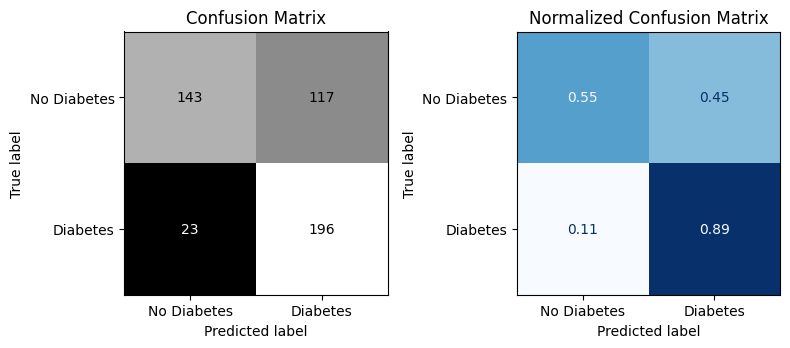


----------------------------------------------------------------------
Classification metrics : Testing Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.95      0.47      0.63       111
    Diabetes       0.44      0.94      0.60        49

    accuracy                           0.61       160
   macro avg       0.69      0.70      0.61       160
weighted avg       0.79      0.61      0.62       160



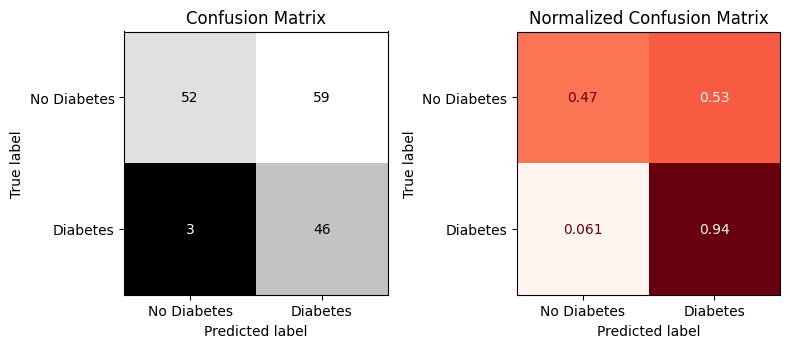

In [622]:
evaluate_with_threshold(grid.best_estimator_, X_train, y_train, X_test, y_test,target_names=['No Diabetes' , 'Diabetes'])

> using thrshold we have improve our testing metrics recall score with more than 25 % from 69 to 94 
* huge differenct and the model become very good for prediction
* best threshold was 0.3 
* we can depend on this model for prediction

## Random Forest Classifier
* because it's a tree model we don't need the scaling pipe

----------------------------------------------------------------------
Classification metrics : Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       1.00      1.00      1.00       260
    Diabetes       1.00      1.00      1.00       219

    accuracy                           1.00       479
   macro avg       1.00      1.00      1.00       479
weighted avg       1.00      1.00      1.00       479



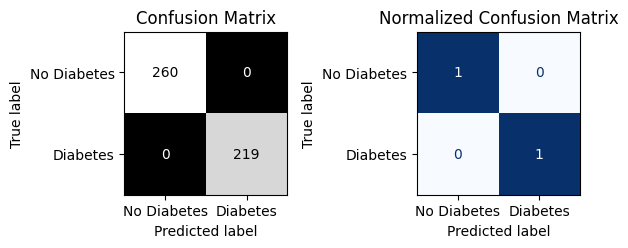


----------------------------------------------------------------------
Classification metrics : Testing Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.85      0.74      0.79       111
    Diabetes       0.54      0.69      0.61        49

    accuracy                           0.72       160
   macro avg       0.69      0.72      0.70       160
weighted avg       0.75      0.72      0.73       160



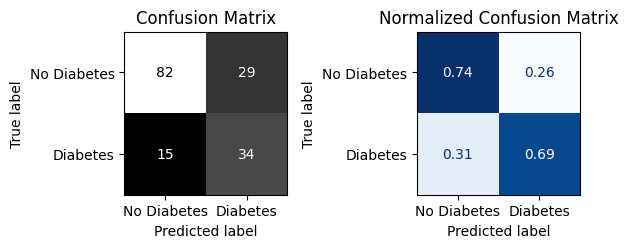

In [623]:
ran_forest = RandomForestClassifier(random_state=42)
ran_forest_pipe = make_pipeline_imb(cols_tranf, SMOTE(random_state=42) , ran_forest)
ran_forest_pipe.fit(X_train , y_train)
evaluation_classification(ran_forest_pipe , X_train , y_train , X_test , y_test , target_names=['No Diabetes' , 'Diabetes'])

> we notice that the model have a huge overfitting and he is not generalizing well 
* so we will try to tune the model 

In [624]:
ran_forest_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('Numeric', SimpleImputer(strategy='median'),
                                    Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
          'DiabetesPedigreeFunction'],
         dtype='str')),
                                   ('ordinal',
                                    OrdinalEncoder(categories=[['underweight',
                                                                'healthy weight',
                                                                'obese_1',
                                                                'obese_2',
                                                                'obese_3',
                                                                'overweight',
                                                                'MISSING'],
                                                               ['18 - 44',
                              

In [544]:
ran_forest = RandomForestClassifier(random_state=42)
ran_forest_pipe = make_pipeline_imb(cols_tranf, SMOTE(random_state=42) , ran_forest)

In [548]:
param_grid_rf = {
    'randomforestclassifier__n_estimators'     : [50,100, 200, 300],
    'randomforestclassifier__max_depth'        : [5, 10,15,20],   
    'randomforestclassifier__min_samples_leaf' : [4, 8, 16],    
    'randomforestclassifier__min_samples_split': [10, 20],       
    'randomforestclassifier__max_features'     : ['sqrt' , 'log2'],
}

In [546]:
grid_rand = GridSearchCV(ran_forest_pipe , param_grid_rf , cv=5 , n_jobs=-1,scoring='recall')
grid_rand.fit(X_train , y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__max_depth': [5, 10, ...], 'randomforestclassifier__max_features': ['sqrt', 'log2'], 'randomforestclassifier__min_samples_leaf': [4, 8, ...], 'randomforestclassifier__min_samples_split': [10, 20], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intCo

----------------------------------------------------------------------
Classification metrics : Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.87      0.80      0.83       260
    Diabetes       0.78      0.86      0.82       219

    accuracy                           0.82       479
   macro avg       0.82      0.83      0.82       479
weighted avg       0.83      0.82      0.82       479



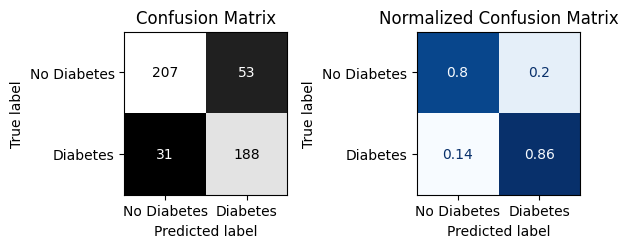


----------------------------------------------------------------------
Classification metrics : Testing Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.87      0.72      0.79       111
    Diabetes       0.54      0.76      0.63        49

    accuracy                           0.73       160
   macro avg       0.71      0.74      0.71       160
weighted avg       0.77      0.73      0.74       160



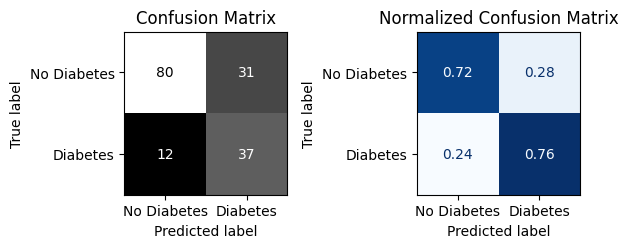

In [547]:
evaluation_classification(grid_rand.best_estimator_ , X_train , y_train , X_test , y_test , target_names=['No Diabetes' , 'Diabetes'])


> Try to tune the threshold

C:\Users\zezo2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\zezo2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


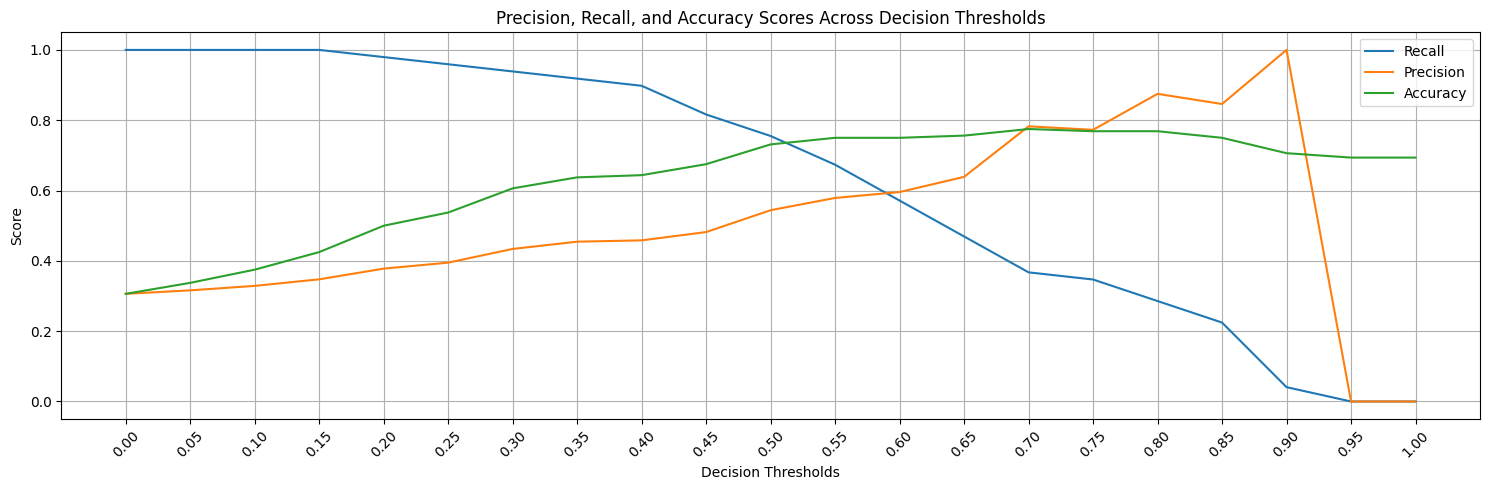

,Threshold,Recall,Precision,Accuracy
0,0.00,1.000,0.306,0.306
1,0.05,1.000,0.316,0.338
2,0.10,1.000,0.329,0.375
3,0.15,1.000,0.348,0.425
4,0.20,0.980,0.378,0.500
5,0.25,0.959,0.395,0.538
6,0.30,0.939,0.434,0.606
7,0.35,0.918,0.455,0.638
8,0.40,0.898,0.458,0.644
9,0.45,0.816,0.482,0.675


In [625]:
plot_threshold_metrics(grid_rand.best_estimator_, X_test, y_test)

  Threshold = 0.3

----------------------------------------------------------------------
Classification metrics : Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.96      0.58      0.73       260
    Diabetes       0.66      0.97      0.79       219

    accuracy                           0.76       479
   macro avg       0.81      0.78      0.76       479
weighted avg       0.83      0.76      0.76       479



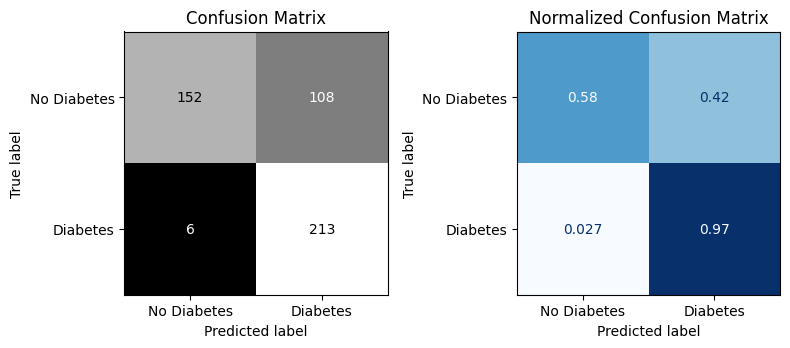


----------------------------------------------------------------------
Classification metrics : Testing Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.94      0.46      0.62       111
    Diabetes       0.43      0.94      0.59        49

    accuracy                           0.61       160
   macro avg       0.69      0.70      0.61       160
weighted avg       0.79      0.61      0.61       160



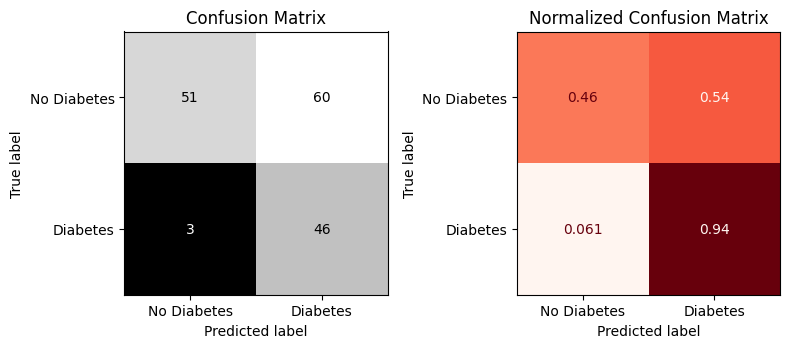

In [630]:
evaluate_with_threshold(grid_rand.best_estimator_, X_train, y_train, X_test,  y_test ,threshold=0.3 ,target_names=['No Diabetes' , 'Diabetes'])

* this is the best model that can be used for prediction

# Conclusion

The best model is Logistic Regression with threshold = 0.3, achieving a Diabetes Recall of 0.94 with no overfitting. This means 94% of diabetic patients are correctly identified — only 6% are missed. The threshold tuning proved to be the most impactful technique, improving recall by over 25% compared to the default threshold. 